# Programming assignment 3: Optimization - Logistic Regression

In [121]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

## Your task

In this notebook code skeleton for performing logistic regression with gradient descent is given. 
Your task is to complete the functions where required. 
You are only allowed to use built-in Python functions, as well as any `numpy` functions. No other libraries / imports are allowed.

For numerical reasons, we actually minimize the following loss function

$$\mathcal{L}(\mathbf{w}) = \frac{1}{N} NLL(\mathbf{w}) +  \frac{1}{2}\lambda ||\mathbf{w}||^2_2$$

where $NLL(\mathbf{w})$ is the negative log-likelihood function, as defined in the lecture (see Slide 39).

## Load and preprocess the data

In this assignment we will work with the UCI ML Breast Cancer Wisconsin (Diagnostic) dataset https://goo.gl/U2Uwz2.

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image. There are 212 malignant examples and 357 benign examples.

In [122]:
X, y = load_breast_cancer(return_X_y=True)

# Add a vector of ones to the data matrix to absorb the bias term
X = np.hstack([np.ones([X.shape[0], 1]), X])

# Set the random seed so that we have reproducible experiments
np.random.seed(123)

# Split into train and test
test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)

## Task 1: Implement the sigmoid function 

In [123]:
def sigmoid(t):
    """
    Applies the sigmoid function elementwise to the input data.
    
    Parameters
    ----------
    t : array, arbitrary shape
        Input data.
        
    Returns
    -------
    t_sigmoid : array, arbitrary shape.
        Data after applying the sigmoid function.
    """
    # TODO
    return 1.0/(1+np.exp(-1.0*t))

## Task 2: Implement the negative log likelihood

As defined in Eq. 33

In [124]:
def negative_log_likelihood(X, y, w):
    """
    Negative Log Likelihood of the Logistic Regression.
    
    Parameters
    ----------
    X : array, shape [N, D]
        (Augmented) feature matrix.
    y : array, shape [N]
        Classification targets.
    w : array, shape [D]
        Regression coefficients (w[0] is the bias term).
        
    Returns
    -------
    nll : float
        The negative log likelihood.
    """
    # TODO
    return np.sum(y * np.log(sigmoid(X@w)) - (1-y) * np.log(1-sigmoid(X@w)), axis=0)

### Computing the loss function $\mathcal{L}(\mathbf{w})$ (nothing to do here)

In [125]:
def compute_loss(X, y, w, lmbda):
    """
    Negative Log Likelihood of the Logistic Regression.
    
    Parameters
    ----------
    X : array, shape [N, D]
        (Augmented) feature matrix.
    y : array, shape [N]
        Classification targets.
    w : array, shape [D]
        Regression coefficients (w[0] is the bias term).
    lmbda : float
        L2 regularization strength.
        
    Returns
    -------
    loss : float
        Loss of the regularized logistic regression model.
    """
    # The bias term w[0] is not regularized by convention
    return negative_log_likelihood(X, y, w) / len(y) + lmbda * 0.5 * np.linalg.norm(w[1:])**2

## Task 3: Implement the gradient $\nabla_{\mathbf{w}}\mathcal{L}(\mathbf{w})$

Make sure that you compute the gradient of the loss function $\mathcal{L}(\mathbf{w})$ (not simply the NLL!)

In [126]:
def get_gradient(X, y, w, mini_batch_indices, lmbda):
    """
    Calculates the gradient (full or mini-batch) of the negative log likelilhood w.r.t. w.
    
    Parameters
    ----------
    X : array, shape [N, D]
        (Augmented) feature matrix.
    y : array, shape [N]
        Classification targets.
    w : array, shape [D]
        Regression coefficients (w[0] is the bias term).
    mini_batch_indices: array, shape [mini_batch_size]
        The indices of the data points to be included in the (stochastic) calculation of the gradient.
        This includes the full batch gradient as well, if mini_batch_indices = np.arange(n_train).
    lmbda: float
        Regularization strentgh. lmbda = 0 means having no regularization.
        
    Returns
    -------
    dw : array, shape [D]
        Gradient w.r.t. w.
    """
    # TODO
    samples = X[mini_batch_indices]
    y_samples = y[mini_batch_indices]
    reg = lmbda * w
    N = len(mini_batch_indices)
    return -samples.T @ (y_samples - sigmoid(samples @ w))/N + reg

### Train the logistic regression model (nothing to do here)

In [127]:
def logistic_regression(X, y, num_steps, learning_rate, mini_batch_size, lmbda, verbose):
    """
    Performs logistic regression with (stochastic) gradient descent.
    
    Parameters
    ----------
    X : array, shape [N, D]
        (Augmented) feature matrix.
    y : array, shape [N]
        Classification targets.
    num_steps : int
        Number of steps of gradient descent to perform.
    learning_rate: float
        The learning rate to use when updating the parameters w.
    mini_batch_size: int
        The number of examples in each mini-batch.
        If mini_batch_size=n_train we perform full batch gradient descent. 
    lmbda: float
        Regularization strentgh. lmbda = 0 means having no regularization.
    verbose : bool
        Whether to print the loss during optimization.
        
    Returns
    -------
    w : array, shape [D]
        Optimal regression coefficients (w[0] is the bias term).
    trace: list
        Trace of the loss function after each step of gradient descent.
    """
    
    trace = [] # saves the value of loss every 50 iterations to be able to plot it later
    n_train = X.shape[0] # number of training instances
    
    w = np.zeros(X.shape[1]) # initialize the parameters to zeros
    
    # run gradient descent for a given number of steps
    for step in range(num_steps):
        permuted_idx = np.random.permutation(n_train) # shuffle the data
        
        # go over each mini-batch and update the paramters
        # if mini_batch_size = n_train we perform full batch GD and this loop runs only once
        for idx in range(0, n_train, mini_batch_size):
            # get the random indices to be included in the mini batch
            mini_batch_indices = permuted_idx[idx:idx+mini_batch_size]
            gradient = get_gradient(X, y, w, mini_batch_indices, lmbda)

            # update the parameters
            w = w - learning_rate * gradient
        
        # calculate and save the current loss value every 50 iterations
        if step % 50 == 0:
            loss = compute_loss(X, y, w, lmbda)
            trace.append(loss)
            # print loss to monitor the progress
            if verbose:
                print('Step {0}, loss = {1:.4f}'.format(step, loss))
    return w, trace

## Task 4: Implement the function to obtain the predictions

In [128]:
def predict(X, w):
    """
    Parameters
    ----------
    X : array, shape [N_test, D]
        (Augmented) feature matrix.
    w : array, shape [D]
        Regression coefficients (w[0] is the bias term).
        
    Returns
    -------
    y_pred : array, shape [N_test]
        A binary array of predictions.
    """
    # TODO
    probs = sigmoid(X @ w)
    return probs > 0.5

### Full batch gradient descent

In [129]:
# Change this to True if you want to see loss values over iterations.
verbose = True

In [130]:
n_train = X_train.shape[0]
w_full, trace_full = logistic_regression(X_train, 
                                         y_train, 
                                         num_steps=8000, 
                                         learning_rate=1e-5, 
                                         mini_batch_size=n_train, 
                                         lmbda=0.1,
                                         verbose=verbose)

Step 0, loss = -0.5714
Step 50, loss = -0.9094
Step 100, loss = -0.4037
Step 150, loss = -0.0879
Step 200, loss = -0.0622
Step 250, loss = -0.0527
Step 300, loss = -0.0451
Step 350, loss = -0.0387
Step 400, loss = -0.0334
Step 450, loss = -0.0288
Step 500, loss = -0.0249
Step 550, loss = -0.0215
Step 600, loss = -0.0185
Step 650, loss = -0.0158
Step 700, loss = -0.0134
Step 750, loss = -0.0112
Step 800, loss = -0.0093
Step 850, loss = -0.0075
Step 900, loss = -0.0059
Step 950, loss = -0.0043
Step 1000, loss = -0.0029
Step 1050, loss = -0.0016
Step 1100, loss = -0.0004
Step 1150, loss = 0.0007
Step 1200, loss = 0.0018
Step 1250, loss = 0.0028
Step 1300, loss = 0.0038
Step 1350, loss = 0.0047
Step 1400, loss = 0.0056
Step 1450, loss = 0.0064
Step 1500, loss = 0.0072
Step 1550, loss = 0.0079
Step 1600, loss = 0.0087
Step 1650, loss = 0.0093
Step 1700, loss = 0.0100
Step 1750, loss = 0.0106
Step 1800, loss = 0.0112
Step 1850, loss = 0.0118
Step 1900, loss = 0.0124
Step 1950, loss = 0.0129


In [131]:
n_train = X_train.shape[0]
w_minibatch, trace_minibatch = logistic_regression(X_train, 
                                                   y_train, 
                                                   num_steps=8000, 
                                                   learning_rate=1e-5, 
                                                   mini_batch_size=50, 
                                                   lmbda=0.1,
                                                   verbose=verbose)

Step 0, loss = 1.0812
Step 50, loss = 0.0308
Step 100, loss = -0.0968
Step 150, loss = 0.0397
Step 200, loss = 0.1079
Step 250, loss = 0.0754
Step 300, loss = 0.0157
Step 350, loss = 0.0545
Step 400, loss = 0.0260
Step 450, loss = -0.0201
Step 500, loss = -0.0195
Step 550, loss = 0.1108
Step 600, loss = 0.0189
Step 650, loss = 0.0615
Step 700, loss = 0.0486
Step 750, loss = -0.0218
Step 800, loss = 0.0260
Step 850, loss = -0.0800
Step 900, loss = 0.0236
Step 950, loss = -0.0116
Step 1000, loss = 0.0479
Step 1050, loss = 0.0890
Step 1100, loss = 0.0447
Step 1150, loss = 0.0358
Step 1200, loss = 0.0104
Step 1250, loss = -0.0107
Step 1300, loss = 0.0679
Step 1350, loss = 0.0273
Step 1400, loss = 0.0546
Step 1450, loss = 0.0379
Step 1500, loss = 0.0326
Step 1550, loss = -0.0090
Step 1600, loss = -0.0430
Step 1650, loss = 0.0069
Step 1700, loss = -0.0329
Step 1750, loss = -0.0022
Step 1800, loss = 0.0159
Step 1850, loss = 0.0857
Step 1900, loss = 0.0399
Step 1950, loss = -0.0727
Step 2000, 

Our reference solution produces, but don't worry if yours is not exactly the same. 

    Full batch: accuracy: 0.9240, f1_score: 0.9384
    Mini-batch: accuracy: 0.9415, f1_score: 0.9533

In [132]:
y_pred_full = predict(X_test, w_full)
y_pred_minibatch = predict(X_test, w_minibatch)

print('Full batch: accuracy: {:.4f}, f1_score: {:.4f}'
      .format(accuracy_score(y_test, y_pred_full), f1_score(y_test, y_pred_full)))
print('Mini-batch: accuracy: {:.4f}, f1_score: {:.4f}'
      .format(accuracy_score(y_test, y_pred_minibatch), f1_score(y_test, y_pred_minibatch)))

Full batch: accuracy: 0.9240, f1_score: 0.9384
Mini-batch: accuracy: 0.9415, f1_score: 0.9533


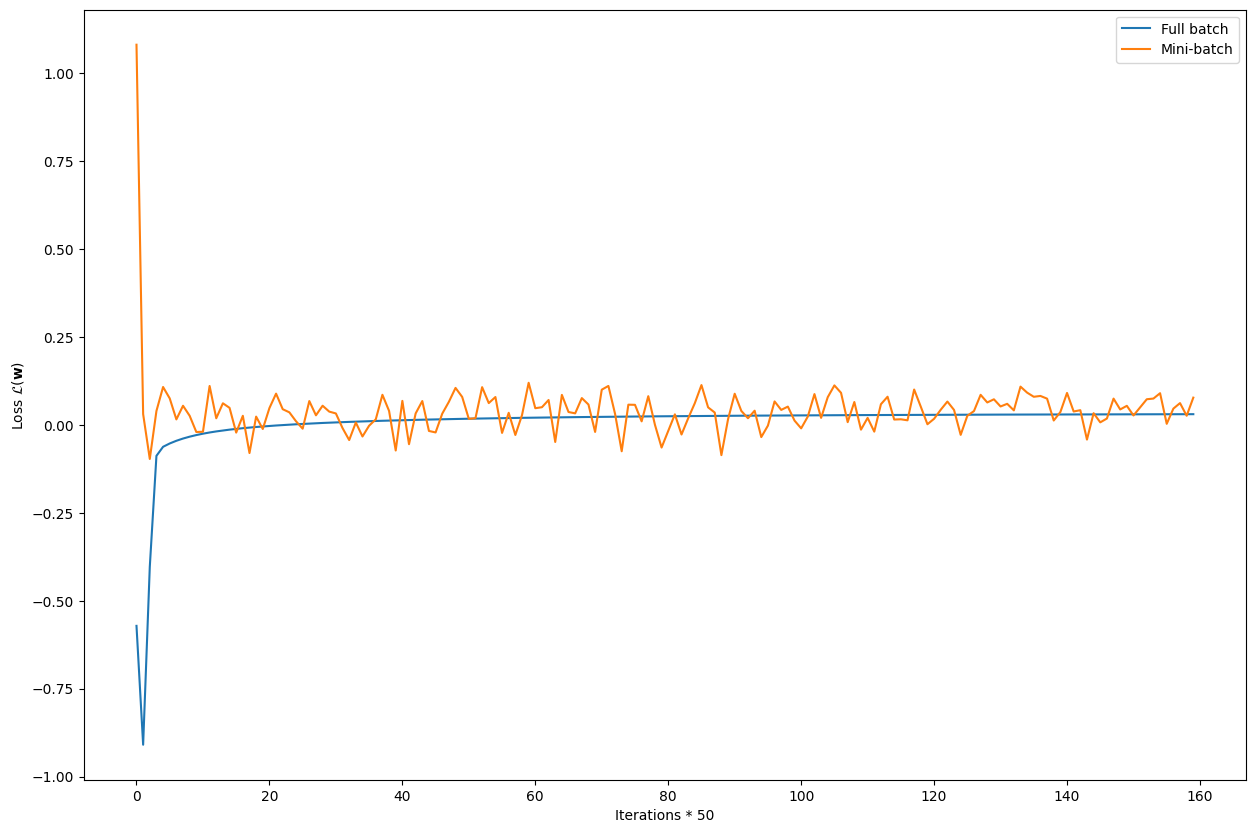

In [133]:
plt.figure(figsize=[15, 10])
plt.plot(trace_full, label='Full batch')
plt.plot(trace_minibatch, label='Mini-batch')
plt.xlabel('Iterations * 50')
plt.ylabel('Loss $\mathcal{L}(\mathbf{w})$')
plt.legend()
plt.show()